# H1 — Baseline Gender Asymmetry: Statistical Tests & Model 1

**Hypothesis:** Female depictions show higher Warmth and lower Competence than male depictions (greater W−C asymmetry).

**Plan:**
1. Statistical tests: Welch's t-test, Cohen's d, Mann-Whitney U (Asymmetry, Warmth, Competence)
2. Model 1: `Asymmetry_i = β₀ + β₁·Female_i + ε_i`
3. Robustness: same model with `Warmth ~ Female` and `Competence ~ Female`
4. Reporting: β₁, 95% CI, p-value, predicted means per gender

**Date:** March 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style (consistent with EDA notebook) ──
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {"Male": "#6dc985", "Female": "#4f2478"}
FIG_DIR = Path("../figures")
# FIG_DIR.mkdir(exist_ok=True, parents=True)

def savefig(fig, name, dpi=150):
    """Save figure if FIG_DIR exists, else just show."""
    try:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    except Exception:
        pass

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Load data ──
# Adjust path as needed
df = pd.read_csv("/Users/marevi/Downloads/analysis_copy/analysis_dataset.csv")

# Filter to Male/Female only
dfa = df[df["gender"].isin(["Male", "Female"])].copy()

# Binary indicator: Female = 1, Male = 0
dfa["female"] = (dfa["gender"] == "Female").astype(int)

print(f"Analysis set: {len(dfa):,} figures")
print(f"  Male:   {(dfa['gender']=='Male').sum():,}")
print(f"  Female: {(dfa['gender']=='Female').sum():,}")
print(f"\nOutcome columns:")
for col in ["asymmetry", "dirmean_Warmth", "dirmean_Competence"]:
    print(f"  {col}: {dfa[col].notna().sum():,} non-null, mean={dfa[col].mean():.4f}")

Analysis set: 18,761 figures
  Male:   12,005
  Female: 6,756

Outcome columns:
  asymmetry: 17,773 non-null, mean=-0.1644
  dirmean_Warmth: 17,826 non-null, mean=0.4006
  dirmean_Competence: 18,704 non-null, mean=0.5553


---
## 1. Descriptive Statistics by Gender

In [3]:
# ── 1a. Summary statistics table ──
summary = dfa.groupby("gender").agg(
    n=("cat_no", "count"),
    warmth_mean=("dirmean_Warmth", "mean"),
    warmth_sd=("dirmean_Warmth", "std"),
    warmth_median=("dirmean_Warmth", "median"),
    competence_mean=("dirmean_Competence", "mean"),
    competence_sd=("dirmean_Competence", "std"),
    competence_median=("dirmean_Competence", "median"),
    asymmetry_mean=("asymmetry", "mean"),
    asymmetry_sd=("asymmetry", "std"),
    asymmetry_median=("asymmetry", "median"),
).round(4)

print("=" * 60)
print("Descriptive Statistics by Gender")
print("=" * 60)
summary

Descriptive Statistics by Gender


,n,warmth_mean,warmth_sd,warmth_median,competence_mean,competence_sd,competence_median,asymmetry_mean,asymmetry_sd,asymmetry_median
gender,,,,,,,,,,
Female,6756,0.4771,0.3773,0.5,0.5048,0.4299,0.625,-0.0407,0.5105,-0.0625
Male,12005,0.3568,0.4184,0.5,0.5835,0.4106,0.750,-0.2347,0.5492,-0.2500


In [4]:
# ── 1b. Raw mean differences (Female − Male) ──
male = dfa[dfa["gender"] == "Male"]
female = dfa[dfa["gender"] == "Female"]

print("Raw mean differences (Female − Male):")
for col, label in [("dirmean_Warmth", "Warmth"), ("dirmean_Competence", "Competence"), ("asymmetry", "Asymmetry")]:
    diff = female[col].mean() - male[col].mean()
    print(f"  {label}: {diff:+.4f}")

Raw mean differences (Female − Male):
  Warmth: +0.1203
  Competence: -0.0787
  Asymmetry: +0.1940


---
## 2. Statistical Tests: Welch's t-test, Cohen's d, Mann-Whitney U

In [5]:
# ── 2a. Helper functions ──

def cohens_d(g1, g2):
    """Cohen's d: standardized mean difference (g1 - g2) using pooled SD."""
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1 - 1) * g1.var() + (n2 - 1) * g2.var()) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / pooled_std


def hedges_g(g1, g2):
    """Hedges' g: bias-corrected Cohen's d for unequal sample sizes."""
    n1, n2 = len(g1), len(g2)
    d = cohens_d(g1, g2)
    correction = 1 - (3 / (4 * (n1 + n2 - 2) - 1))
    return d * correction


def rank_biserial_r(u_stat, n1, n2):
    """Rank-biserial correlation (effect size for Mann-Whitney U)."""
    return 1 - (2 * u_stat) / (n1 * n2)


def interpret_d(d):
    """Cohen's d interpretation (absolute value)."""
    d_abs = abs(d)
    if d_abs < 0.2:   return "negligible"
    elif d_abs < 0.5: return "small"
    elif d_abs < 0.8: return "medium"
    else:             return "large"


print("Helper functions defined.")

Helper functions defined.


In [6]:
# ── 2b. Run all tests ──

OUTCOMES = [
    ("asymmetry",         "Asymmetry (W−C)"),
    ("dirmean_Warmth",    "Warmth"),
    ("dirmean_Competence","Competence"),
]

results_tests = []

print("=" * 80)
print("STATISTICAL TESTS: Male vs Female (direction: Female − Male)")
print("=" * 80)

for col, label in OUTCOMES:
    m = male[col].dropna()
    f = female[col].dropna()
    
    # Welch's t-test (does not assume equal variances)
    t_stat, t_p = stats.ttest_ind(f, m, equal_var=False)
    
    # Degrees of freedom (Welch-Satterthwaite approximation)
    s1, s2, n1, n2 = f.std(), m.std(), len(f), len(m)
    df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
    
    # 95% CI on the mean difference
    se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
    t_crit = stats.t.ppf(0.975, df=df_welch)
    mean_diff = f.mean() - m.mean()
    ci_lo = mean_diff - t_crit * se_diff
    ci_hi = mean_diff + t_crit * se_diff
    
    # Effect sizes
    d = cohens_d(f, m)
    g = hedges_g(f, m)
    
    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(f, m, alternative="two-sided")
    r_rb = rank_biserial_r(u_stat, n1, n2)
    
    results_tests.append({
        "outcome": label,
        "n_female": n1, "mean_female": f.mean(), "sd_female": f.std(),
        "n_male": n2, "mean_male": m.mean(), "sd_male": m.std(),
        "mean_diff": mean_diff, "ci_lo": ci_lo, "ci_hi": ci_hi,
        "cohens_d": d, "hedges_g": g, "effect_size_interp": interpret_d(d),
        "welch_t": t_stat, "welch_df": df_welch, "welch_p": t_p,
        "mw_U": u_stat, "mw_p": u_p, "rank_biserial_r": r_rb,
    })
    
    # Print summary
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    print(f"  Female:  mean={f.mean():.4f}, SD={f.std():.4f}, n={n1:,}")
    print(f"  Male:    mean={m.mean():.4f}, SD={m.std():.4f}, n={n2:,}")
    print(f"  Δ (F−M): {mean_diff:+.4f}  [95% CI: {ci_lo:+.4f}, {ci_hi:+.4f}]")
    print(f"  Cohen's d = {d:+.4f}  ({interpret_d(d)})")
    print(f"  Hedges' g = {g:+.4f}")
    print(f"  Welch's t({df_welch:.0f}) = {t_stat:.3f},  p = {t_p:.3e}")
    print(f"  Mann-Whitney U = {u_stat:.0f},  p = {u_p:.3e},  r_rb = {r_rb:+.4f}")

print(f"\n{'='*80}")

df_tests = pd.DataFrame(results_tests)
df_tests.set_index("outcome")

STATISTICAL TESTS: Male vs Female (direction: Female − Male)

────────────────────────────────────────────────────────────
  Asymmetry (W−C)
────────────────────────────────────────────────────────────
  Female:  mean=-0.0407, SD=0.5105, n=6,440
  Male:    mean=-0.2347, SD=0.5492, n=11,333
  Δ (F−M): +0.1940  [95% CI: +0.1779, +0.2100]
  Cohen's d = +0.3622  (small)
  Hedges' g = +0.3622
  Welch's t(14202) = 23.681,  p = 1.267e-121
  Mann-Whitney U = 44264792,  p = 1.303e-123,  r_rb = -0.2130

────────────────────────────────────────────────────────────
  Warmth
────────────────────────────────────────────────────────────
  Female:  mean=0.4771, SD=0.3773, n=6,482
  Male:    mean=0.3568, SD=0.4184, n=11,344
  Δ (F−M): +0.1203  [95% CI: +0.1083, +0.1323]
  Cohen's d = +0.2978  (small)
  Hedges' g = +0.2977
  Welch's t(14654) = 19.669,  p = 4.969e-85
  Mann-Whitney U = 43287591,  p = 5.138e-88,  r_rb = -0.1774

────────────────────────────────────────────────────────────
  Competence
───

,n_female,mean_female,sd_female,n_male,mean_male,sd_male,mean_diff,ci_lo,ci_hi,cohens_d,hedges_g,effect_size_interp,welch_t,welch_df,welch_p,mw_U,mw_p,rank_biserial_r
outcome,,,,,,,,,,,,,,,,,,
Asymmetry (W−C),6440,-0.040720,0.510516,11333,-0.234679,0.549192,0.193959,0.177905,0.210014,0.362201,0.362186,small,23.681122,14202.408133,1.266780e-121,44264792.5,1.303438e-123,-0.212991
Warmth,6482,0.477094,0.377293,11344,0.356822,0.418381,0.120272,0.108286,0.132257,0.297757,0.297745,small,19.668819,14654.470572,4.969177e-85,43287591.0,5.138364e-88,-0.177384
Competence,6712,0.504825,0.429909,11992,0.583500,0.410618,-0.078675,-0.091317,-0.066034,-0.188380,-0.188372,negligible,-12.198712,13363.981502,4.790267e-34,35594879.0,1.663083e-39,0.115549


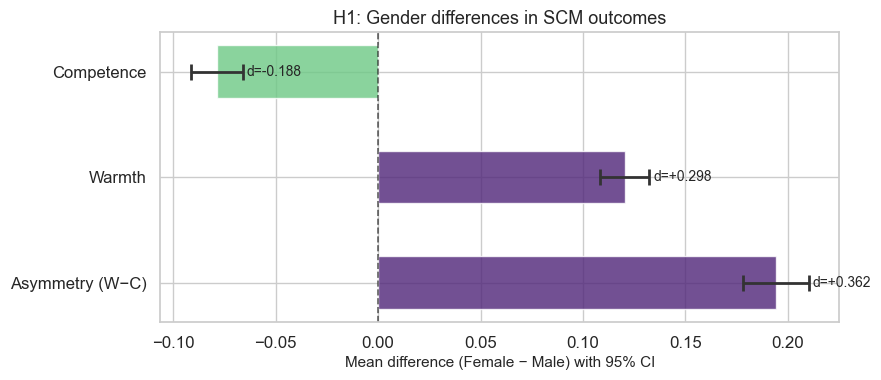

In [7]:
# ── 2c. Forest plot: Mean differences with 95% CI ──
fig, ax = plt.subplots(figsize=(9, 4))

labels = df_tests["outcome"].tolist()
means = df_tests["mean_diff"].values
ci_lo = df_tests["ci_lo"].values
ci_hi = df_tests["ci_hi"].values
ds = df_tests["cohens_d"].values

y_pos = np.arange(len(labels))
colors_forest = ["#4f2478" if m > 0 else "#6dc985" for m in means]

ax.barh(y_pos, means, xerr=np.array([means - ci_lo, ci_hi - means]),
        height=0.5, color=colors_forest, alpha=0.8, capsize=6,
        error_kw={"elinewidth": 2, "capthick": 2, "ecolor": "#333"})

for i, (m, lo, hi, d) in enumerate(zip(means, ci_lo, ci_hi, ds)):
    ax.text(hi + 0.002, i, f"d={d:+.3f}", va="center", fontsize=10)

ax.axvline(0, color="black", lw=1.2, ls="--", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("Mean difference (Female − Male) with 95% CI", fontsize=11)
ax.set_title("H1: Gender differences in SCM outcomes", fontsize=13)
ax.annotate("← Female lower", xy=(ax.get_xlim()[0] + 0.001, -0.6), fontsize=9, color="gray")
ax.annotate("Female higher →", xy=(0.002, -0.6), fontsize=9, color="gray")

plt.tight_layout()
savefig(fig, "h1_01_forest_plot")
plt.show()

Female figures are consistently portrayed as warmer than male figures.

Male figures are depicted as slightly more competent than female figures.

Female figures exhibit a stronger warmth–competence imbalance (high warmth, lower competence) compared to males.

The results provide strong support for H1. Female figures are depicted as significantly higher in warmth than male figures (d = 0.298), while male figures exhibit slightly higher competence (d = −0.188). Crucially, the warmth–competence asymmetry is significantly greater for female figures (d = 0.362), indicating that women are systematically portrayed as warmer relative to their competence compared to men.

---
## 3. Model 1: OLS Regression — Asymmetry ~ Female

$$\text{Asymmetry}_i = \beta_0 + \beta_1 \cdot \text{Female}_i + \varepsilon_i$$

- $\beta_0$ = predicted asymmetry for **Male** (reference group)
- $\beta_1$ = difference in asymmetry for **Female** vs. Male
- Equivalent to Welch's t-test, but frames results as a regression coefficient with CI

In [8]:
# ── 3a. Fit Model 1: Asymmetry ~ Female ──

model1 = smf.ols("asymmetry ~ female", data=dfa).fit(
    cov_type="HC3"  # heteroskedasticity-robust standard errors
)

print("=" * 70)
print("Model 1: Asymmetry ~ Female (HC3 robust SEs)")
print("=" * 70)
print(model1.summary())

Model 1: Asymmetry ~ Female (HC3 robust SEs)
                            OLS Regression Results                            
Dep. Variable:              asymmetry   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     560.7
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.52e-122
Time:                        18:47:05   Log-Likelihood:                -14118.
No. Observations:               17773   AIC:                         2.824e+04
Df Residuals:                   17771   BIC:                         2.825e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interce

Results indicate that female figures exhibit significantly higher asymmetry than male figures (β = 0.194, p < .001, 95% CI [0.178, 0.210]). The intercept shows that male figures display a negative asymmetry (β = −0.235), indicating a relative emphasis on competence over warmth. In contrast, female figures shift toward higher warmth relative to competence.

In [9]:
# ── 3b. Extract key results for reporting ──

b0 = model1.params["Intercept"]
b1 = model1.params["female"]
ci = model1.conf_int(alpha=0.05)
b1_lo, b1_hi = ci.loc["female"]
p1 = model1.pvalues["female"]
r2 = model1.rsquared
n_obs = int(model1.nobs)

# Predicted means
pred_male   = b0
pred_female = b0 + b1

print("─" * 50)
print("MODEL 1 RESULTS SUMMARY")
print("─" * 50)
print(f"N observations:    {n_obs:,}")
print(f"R²:                {r2:.4f}")
print()
print(f"β₀ (Male mean):    {b0:+.4f}")
print(f"β₁ (Female − Male):{b1:+.4f}  [95% CI: {b1_lo:+.4f}, {b1_hi:+.4f}]")
print(f"p-value (β₁):      {p1:.3e}")
print()
print(f"Predicted mean — Male:   {pred_male:.4f}")
print(f"Predicted mean — Female: {pred_female:.4f}")
print(f"Difference:              {b1:+.4f}")
print()
print(f"Interpretation: Female depictions score {abs(b1):.4f} units {'higher' if b1>0 else 'lower'}")
print(f"on the W−C asymmetry index compared to male depictions (p {'< 0.001' if p1 < 0.001 else f'= {p1:.3f}'}).")

──────────────────────────────────────────────────
MODEL 1 RESULTS SUMMARY
──────────────────────────────────────────────────
N observations:    17,773
R²:                0.0294

β₀ (Male mean):    -0.2347
β₁ (Female − Male):+0.1940  [95% CI: +0.1779, +0.2100]
p-value (β₁):      5.851e-124

Predicted mean — Male:   -0.2347
Predicted mean — Female: -0.0407
Difference:              +0.1940

Interpretation: Female depictions score 0.1940 units higher
on the W−C asymmetry index compared to male depictions (p < 0.001).


---
## 4. Robustness: Warmth ~ Female and Competence ~ Female

In [10]:
# ── 4a. Robustness models: Warmth and Competence separately ──

model_warmth = smf.ols("dirmean_Warmth ~ female", data=dfa).fit(cov_type="HC3")
model_comp   = smf.ols("dirmean_Competence ~ female", data=dfa).fit(cov_type="HC3")

robustness_rows = []

for label, model, dv in [
    ("Asymmetry (W−C)", model1, "asymmetry"),
    ("Warmth",          model_warmth, "dirmean_Warmth"),
    ("Competence",      model_comp,   "dirmean_Competence"),
]:
    b0_  = model.params["Intercept"]
    b1_  = model.params["female"]
    ci_  = model.conf_int().loc["female"]
    p_   = model.pvalues["female"]
    r2_  = model.rsquared
    
    robustness_rows.append({
        "Outcome": label,
        "β₀ (Male)": round(b0_, 4),
        "β₁ (Female)": round(b1_, 4),
        "95% CI lower": round(ci_.iloc[0], 4),
        "95% CI upper": round(ci_.iloc[1], 4),
        "p-value": f"{p_:.3e}",
        "Pred. Male": round(b0_, 4),
        "Pred. Female": round(b0_ + b1_, 4),
        "R²": round(r2_, 4),
    })

df_robustness = pd.DataFrame(robustness_rows).set_index("Outcome")
print("─" * 80)
print("ROBUSTNESS TABLE: Asymmetry, Warmth, Competence ~ Female (OLS, HC3 SEs)")
print("─" * 80)
df_robustness

────────────────────────────────────────────────────────────────────────────────
ROBUSTNESS TABLE: Asymmetry, Warmth, Competence ~ Female (OLS, HC3 SEs)
────────────────────────────────────────────────────────────────────────────────


,β₀ (Male),β₁ (Female),95% CI lower,95% CI upper,p-value,Pred. Male,Pred. Female,R²
Outcome,,,,,,,,
Asymmetry (W−C),-0.2347,0.1940,0.1779,0.2100,5.851e-124,-0.2347,-0.0407,0.0294
Warmth,0.3568,0.1203,0.1083,0.1323,4.089e-86,0.3568,0.4771,0.0201
Competence,0.5835,-0.0787,-0.0913,-0.0660,3.188e-34,0.5835,0.5048,0.0081


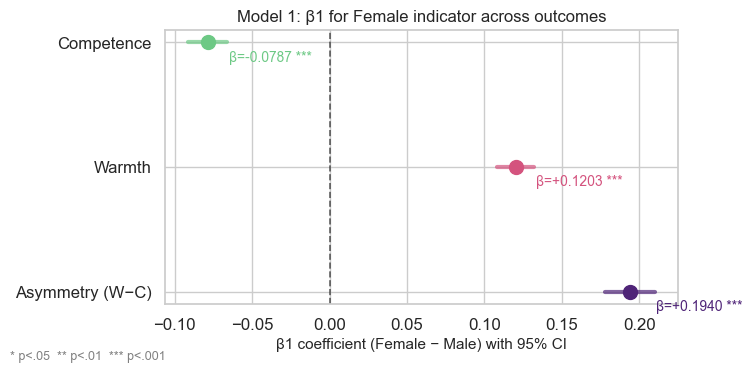

In [18]:
# ── 4b. Coefficient plot: β₁ across all three models ──

fig, ax = plt.subplots(figsize=(8, 4))

outcomes = ["Asymmetry (W−C)", "Warmth", "Competence"]
models   = [model1, model_warmth, model_comp]
plot_colors = ["#4f2478", "#D4537E", "#6dc985"]

y_pos = np.arange(len(outcomes))

for i, (label, m, col) in enumerate(zip(outcomes, models, plot_colors)):
    b = m.params["female"]
    ci_m = m.conf_int().loc["female"]
    lo, hi = ci_m.iloc[0], ci_m.iloc[1]
    p = m.pvalues["female"]
    
    sig_marker = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    
    ax.plot([lo, hi], [i, i], lw=3, color=col, alpha=0.7, solid_capstyle="round")
    ax.plot(b, i, "o", ms=10, color=col, zorder=5)
    ax.text(hi + 0.001, i + -0.15, f"β={b:+.4f} {sig_marker}", fontsize=10, color=col)

ax.axvline(0, color="black", lw=1.2, ls="--", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes, fontsize=12)
ax.set_xlabel("β1 coefficient (Female − Male) with 95% CI", fontsize=11)
ax.set_title("Model 1: β1 for Female indicator across outcomes", fontsize=12)
ax.text(ax.get_xlim()[0] + -0.1, -0.55, "* p<.05  ** p<.01  *** p<.001", fontsize=9, color="gray")

plt.tight_layout()
savefig(fig, "h1_02_coefficient_plot")
plt.show()

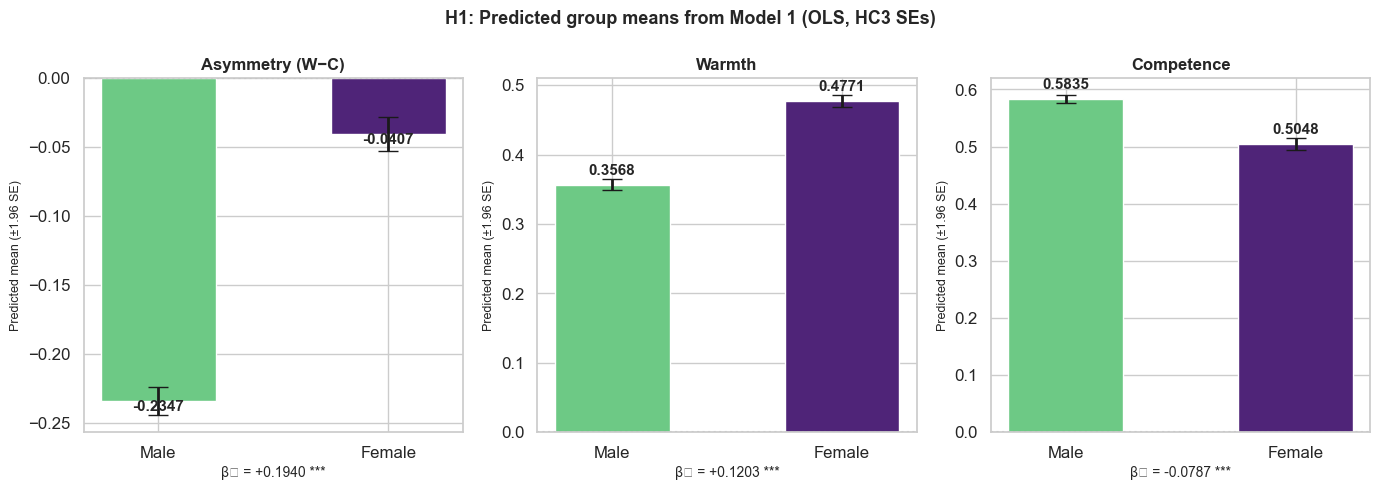

In [12]:
# ── 4c. Predicted means plot ──

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (label, m) in enumerate(zip(outcomes, models)):
    b0_ = m.params["Intercept"]
    b1_ = m.params["female"]
    ci_ = m.conf_int().loc["female"]
    p_ = m.pvalues["female"]
    
    pred_means = {"Male": b0_, "Female": b0_ + b1_}
    
    # SE of each predicted mean
    se_b0 = m.bse["Intercept"]
    se_b1 = m.bse["female"]
    se_female = np.sqrt(se_b0**2 + se_b1**2 + 2 * m.cov_params().loc["Intercept", "female"])
    
    pred_se = {"Male": se_b0, "Female": se_female}
    
    genders = ["Male", "Female"]
    vals = [pred_means[g] for g in genders]
    ses = [pred_se[g] for g in genders]
    cols_ = [COLORS[g] for g in genders]
    
    bars = axes[i].bar(genders, vals,
                       yerr=[1.96 * s for s in ses],
                       color=cols_, edgecolor="white", width=0.5,
                       capsize=7, error_kw={"elinewidth": 2})
    
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     v + (max(vals) * 0.03 if v >= 0 else min(vals) * 0.03),
                     f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
    
    axes[i].axhline(0, color="gray", ls=":", alpha=0.5)
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Predicted mean (±1.96 SE)", fontsize=9)
    
    sig = "***" if p_ < 0.001 else ("**" if p_ < 0.01 else ("*" if p_ < 0.05 else "ns"))
    axes[i].set_xlabel(f"β₁ = {b1_:+.4f} {sig}", fontsize=10)

plt.suptitle("H1: Predicted group means from Model 1 (OLS, HC3 SEs)", fontsize=13, fontweight="bold")
plt.tight_layout()
savefig(fig, "h1_03_predicted_means")
plt.show()

---
## 5. Model Diagnostics

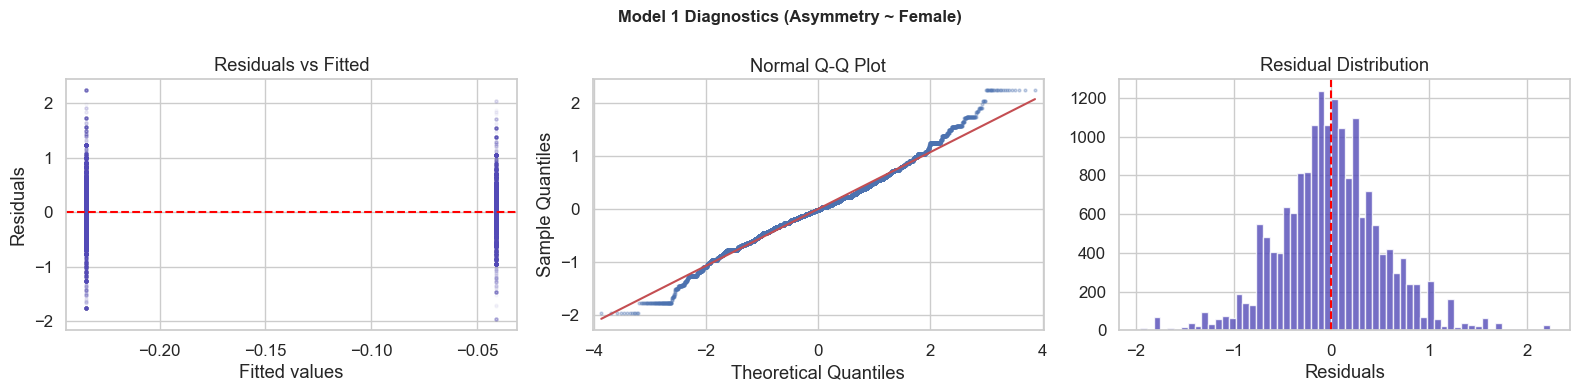


Levene's test for equality of variances:
  F = 18.054, p = 2.158e-05
  → Variances differ significantly — HC3 SEs justified.


In [28]:
# ── 5a. Residual diagnostics for Model 1 ──

residuals = model1.resid
fitted    = model1.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs fitted
axes[0].scatter(fitted, residuals, alpha=0.03, s=5, color="#534AB7")
axes[0].axhline(0, color="red", ls="--", lw=1.5)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# QQ plot
sm.qqplot(residuals, line="s", ax=axes[1], alpha=0.3, ms=2)
axes[1].set_title("Normal Q-Q Plot")

# Residual histogram
axes[2].hist(residuals, bins=60, color="#534AB7", alpha=0.8, edgecolor="white")
axes[2].set_xlabel("Residuals")
axes[2].set_title("Residual Distribution")
axes[2].axvline(0, color="red", ls="--")

plt.suptitle("Model 1 Diagnostics (Asymmetry ~ Female)", fontsize=12, fontweight="bold")
plt.tight_layout()
savefig(fig, "h1_04_diagnostics")
plt.show()

# Levene's test for equal variances
lev_stat, lev_p = stats.levene(
    female["asymmetry"].dropna(), male["asymmetry"].dropna()
)
print(f"\nLevene's test for equality of variances:")
print(f"  F = {lev_stat:.3f}, p = {lev_p:.3e}")
print(f"  → {'Variances differ significantly — HC3 SEs justified.' if lev_p < 0.05 else 'No significant difference in variances.'}")

---
## 6. Robustness Checks

### 6a. Clustered Standard Errors (by artwork)
Figures within the same painting are not independent. Clustering SEs by artwork accounts for this.

In [21]:
# ── 6a. Clustered standard errors by artwork ──

# Drop rows with missing asymmetry (model drops them silently, groups vector must match)
dfa_clean = dfa.dropna(subset=["asymmetry"]).copy()

model1_cluster = smf.ols("asymmetry ~ female", data=dfa_clean).fit(
    cov_type="cluster",
    cov_kwds={"groups": dfa_clean["cat_no"]}
)


# Compare HC3 vs Clustered
print("=" * 70)
print("COMPARISON: HC3 vs Clustered SEs (by artwork)")
print("=" * 70)

comparison = pd.DataFrame({
    "HC3": {
        "β₁ (Female)": model1.params["female"],
        "SE": model1.bse["female"],
        "95% CI lower": model1.conf_int().loc["female", 0],
        "95% CI upper": model1.conf_int().loc["female", 1],
        "p-value": model1.pvalues["female"],
    },
    "Clustered (artwork)": {
        "β₁ (Female)": model1_cluster.params["female"],
        "SE": model1_cluster.bse["female"],
        "95% CI lower": model1_cluster.conf_int().loc["female", 0],
        "95% CI upper": model1_cluster.conf_int().loc["female", 1],
        "p-value": model1_cluster.pvalues["female"],
    }
})

print(comparison.round(4).to_string())
print(f"\nSE ratio (clustered / HC3): {model1_cluster.bse['female'] / model1.bse['female']:.2f}x")

# Also run for Warmth and Competence
model_w_cluster = smf.ols("dirmean_Warmth ~ female", 
                           data=dfa.dropna(subset=["dirmean_Warmth"])).fit(
    cov_type="cluster", 
    cov_kwds={"groups": dfa.dropna(subset=["dirmean_Warmth"])["cat_no"]}
)

model_c_cluster = smf.ols("dirmean_Competence ~ female", 
                           data=dfa.dropna(subset=["dirmean_Competence"])).fit(
    cov_type="cluster", 
    cov_kwds={"groups": dfa.dropna(subset=["dirmean_Competence"])["cat_no"]}
)

print("\n\nAll three outcomes — Clustered SEs:")
for label, m in [("Asymmetry", model1_cluster), 
                  ("Warmth", model_w_cluster), 
                  ("Competence", model_c_cluster)]:
    b = m.params["female"]
    ci = m.conf_int().loc["female"]
    p = m.pvalues["female"]
    print(f"  {label:12s}: β₁ = {b:+.4f}  [{ci[0]:+.4f}, {ci[1]:+.4f}]  p = {p:.2e}")

COMPARISON: HC3 vs Clustered SEs (by artwork)
                 HC3  Clustered (artwork)
β₁ (Female)   0.1940               0.1940
SE            0.0082               0.0088
95% CI lower  0.1779               0.1767
95% CI upper  0.2100               0.2112
p-value       0.0000               0.0000

SE ratio (clustered / HC3): 1.07x


All three outcomes — Clustered SEs:
  Asymmetry   : β₁ = +0.1940  [+0.1767, +0.2112]  p = 1.26e-107
  Warmth      : β₁ = +0.1203  [+0.1075, +0.1331]  p = 9.97e-76
  Competence  : β₁ = -0.0787  [-0.0931, -0.0643]  p = 7.94e-27


### 6b. Century Control
Check whether the gender effect survives after controlling for time period.

In [25]:
# ── 6b. Century as fixed-effect control ──

# Parse century to numeric (same logic as EDA notebook)
import re

def parse_century_str(val):
    if pd.isna(val) or val is None or str(val).strip() == "":
        return None
    match = re.search(r"(\d+)", str(val))
    return int(match.group(1)) if match else None

dfa_clean["century_num"] = dfa_clean["century"].apply(parse_century_str)

print(f"Figures with parsed century: {dfa_clean['century_num'].notna().sum():,}")
print(f"Century distribution:\n{dfa_clean['century_num'].value_counts().sort_index()}\n")

# Model with century fixed effects
model1_century = smf.ols("asymmetry ~ female + C(century_num)", data=dfa_clean).fit(
    cov_type="HC3"
)

print("=" * 70)
print("Model 1 + Century FE: Asymmetry ~ Female + C(century)")
print("=" * 70)
print(f"β₁ (Female):  {model1_century.params['female']:+.4f}")
ci_c = model1_century.conf_int().loc["female"]
print(f"95% CI:       [{ci_c[0]:+.4f}, {ci_c[1]:+.4f}]")
print(f"p-value:      {model1_century.pvalues['female']:.2e}")
print(f"R²:           {model1_century.rsquared:.4f}")
print(f"R² (Model 1): {model1.rsquared:.4f}")
print(f"R² gain:      +{model1_century.rsquared - model1.rsquared:.4f}")

# Compare: original vs century-controlled
print(f"\n\nCOMPARISON:")
print(f"  Without century: β₁ = {model1.params['female']:+.4f}  p = {model1.pvalues['female']:.2e}")
print(f"  With century:    β₁ = {model1_century.params['female']:+.4f}  p = {model1_century.pvalues['female']:.2e}")
print(f"  Change in β₁:   {model1_century.params['female'] - model1.params['female']:+.4f}")

Figures with parsed century: 17,773
Century distribution:
century_num
12      64
13      24
14      33
15     627
16    2117
17    7505
18    2662
19    4008
20     733
Name: count, dtype: int64

Model 1 + Century FE: Asymmetry ~ Female + C(century)
β₁ (Female):  +0.1927
95% CI:       [+0.1766, +0.2089]
p-value:      6.29e-121
R²:           0.0317
R² (Model 1): 0.0294
R² gain:      +0.0023


COMPARISON:
  Without century: β₁ = +0.1940  p = 5.85e-124
  With century:    β₁ = +0.1927  p = 6.29e-121
  Change in β₁:   -0.0012


### 6c. Both: Clustered SEs + Century Control
The most conservative specification.

In [26]:
# ── 6c. Most conservative: clustered SEs + century FE ──

model1_full = smf.ols("asymmetry ~ female + C(century_num)", data=dfa_clean).fit(
    cov_type="cluster",
    cov_kwds={"groups": dfa_clean["cat_no"]}
)

print("=" * 70)
print("MOST CONSERVATIVE: Asymmetry ~ Female + C(century), clustered by artwork")
print("=" * 70)
print(f"β₁ (Female):  {model1_full.params['female']:+.4f}")
ci_f = model1_full.conf_int().loc["female"]
print(f"95% CI:       [{ci_f[0]:+.4f}, {ci_f[1]:+.4f}]")
print(f"p-value:      {model1_full.pvalues['female']:.2e}")
print(f"R²:           {model1_full.rsquared:.4f}")

# Summary comparison table
print("\n\n" + "=" * 70)
print("H1 ROBUSTNESS SUMMARY")
print("=" * 70)

specs = [
    ("OLS + HC3 (primary)", model1),
    ("OLS + Clustered SE", model1_cluster),
    ("OLS + HC3 + Century FE", model1_century),
    ("OLS + Clustered + Century FE", model1_full),
]

rows = []
for label, m in specs:
    b = m.params["female"]
    ci = m.conf_int().loc["female"]
    p = m.pvalues["female"]
    r2 = m.rsquared
    rows.append({
        "Specification": label,
        "β₁ (Female)": f"{b:+.4f}",
        "95% CI": f"[{ci[0]:+.4f}, {ci[1]:+.4f}]",
        "p-value": f"{p:.2e}",
        "R²": f"{r2:.4f}",
    })

robustness_df = pd.DataFrame(rows)
print(robustness_df.to_string(index=False))

MOST CONSERVATIVE: Asymmetry ~ Female + C(century), clustered by artwork
β₁ (Female):  +0.1927
95% CI:       [+0.1753, +0.2101]
p-value:      1.33e-104
R²:           0.0317


H1 ROBUSTNESS SUMMARY
               Specification β₁ (Female)             95% CI   p-value     R²
         OLS + HC3 (primary)     +0.1940 [+0.1779, +0.2100] 5.85e-124 0.0294
          OLS + Clustered SE     +0.1940 [+0.1767, +0.2112] 1.26e-107 0.0294
      OLS + HC3 + Century FE     +0.1927 [+0.1766, +0.2089] 6.29e-121 0.0317
OLS + Clustered + Century FE     +0.1927 [+0.1753, +0.2101] 1.33e-104 0.0317


---
## 7. H1 Results Summary

In [ ]:
print("=" * 80)
print("H1 RESULTS SUMMARY")
print("Hypothesis: Female depictions show higher W and lower C (greater W−C asymmetry)")
print("=" * 80)

# Main results
for row in robustness_rows:
    p_val = float(row["p-value"])
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    direction = "↑ (Female higher)" if row["β₁ (Female)"] > 0 else "↓ (Female lower)"
    print(f"\n  {row['Outcome']}:")
    print(f"    Predicted Male={row['β₀ (Male)']:.4f}, Female={row['Pred. Female']:.4f}")
    print(f"    β₁ = {row['β₁ (Female)']:+.4f}  [95% CI: {row['95% CI lower']:+.4f}, {row['95% CI upper']:+.4f}]")
    print(f"    p = {row['p-value']}  {sig}  {direction}")

print()
print("Effect sizes (Cohen's d, Female − Male):")
for row in df_tests.to_dict("records"):
    print(f"  {row['outcome']}: d = {row['cohens_d']:+.4f} ({row['effect_size_interp']})")

print()
print("Mann-Whitney U (non-parametric robustness):")
for row in df_tests.to_dict("records"):
    print(f"  {row['outcome']}: U={row['mw_U']:.0f}, p={row['mw_p']:.3e}, r_rb={row['rank_biserial_r']:+.4f}")

# Robustness checks
print()
print("-" * 80)
print("ROBUSTNESS CHECKS")
print("-" * 80)
print(robustness_df.to_string(index=False))

print()
print("-" * 80)
print("VERDICT")
print("-" * 80)
b1_asym = model1.params["female"]
p_asym  = model1.pvalues["female"]
b1_robust = model1_full.params["female"] 
p_robust  = model1_full.pvalues["female"]

if b1_asym > 0 and p_asym < 0.05:
    print("  ✓ H1 SUPPORTED: Female depictions show significantly higher W−C asymmetry.")
    print(f"    Primary:            β₁ = {b1_asym:+.4f}, p = {p_asym:.2e}")
    print(f"    Most conservative:  β₁ = {b1_robust:+.4f}, p = {p_robust:.2e}")
    print("    Effect survives clustered SEs, century controls, and both combined.")
elif p_asym >= 0.05:
    print("  ✗ H1 NOT SUPPORTED: No significant difference in asymmetry.")
else:
    print("  ~ H1 PARTIALLY SUPPORTED: Significant but in unexpected direction.")

H1 RESULTS SUMMARY
Hypothesis: Female depictions show higher W and lower C (greater W−C asymmetry)

  Asymmetry (W−C):
    Predicted Male=-0.2347, Female=-0.0407
    β₁ = +0.1940  [95% CI: +0.1779, +0.2100]
    p = 5.851e-124  ***  ↑ (Female higher)

  Warmth:
    Predicted Male=0.3568, Female=0.4771
    β₁ = +0.1203  [95% CI: +0.1083, +0.1323]
    p = 4.089e-86  ***  ↑ (Female higher)

  Competence:
    Predicted Male=0.5835, Female=0.5048
    β₁ = -0.0787  [95% CI: -0.0913, -0.0660]
    p = 3.188e-34  ***  ↓ (Female lower)

Effect sizes (Cohen's d, Female − Male):
  Asymmetry (W−C): d = +0.3622 (small)
  Warmth: d = +0.2978 (small)
  Competence: d = -0.1884 (negligible)

Mann-Whitney U (non-parametric robustness):
  Asymmetry (W−C): U=44264792, p=1.303e-123, r_rb=-0.2130
  Warmth: U=43287591, p=5.138e-88, r_rb=-0.1774
  Competence: U=35594879, p=1.663e-39, r_rb=+0.1155

--------------------------------------------------------------------------------
ROBUSTNESS CHECKS
----------------